<a href="https://colab.research.google.com/github/balaji-kubendiran/RPS-Pretraiined-model/blob/main/RPS%20using%20mobilev3net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


!unzip -q -o /content/drive/MyDrive/ML.zip -d /content/dataset


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [ ]:
dataset_path = "/content/dataset/ML/rps-cv-images"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 2188 files belonging to 3 classes.
Using 1751 files for training.
Found 2188 files belonging to 3 classes.
Using 437 files for validation.
Classes: ['paper', 'rock', 'scissors']


In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.3),
])


In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224,224,3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation="softmax")
])


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_mobilenetv3.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6531 - loss: 0.7632 - val_accuracy: 0.9634 - val_loss: 0.1292
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9380 - loss: 0.1957 - val_accuracy: 0.9817 - val_loss: 0.0724
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9601 - loss: 0.1295 - val_accuracy: 0.9771 - val_loss: 0.0641
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9572 - loss: 0.1409 - val_accuracy: 0.9886 - val_loss: 0.0426
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9751 - loss: 0.0796 - val_accuracy: 0.9863 - val_loss: 0.0508
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9709 - loss: 0.0809 - val_accuracy: 0.9886 - val_loss: 0.0238
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9797 - loss: 0.0690 - val_accuracy: 0.9931 - val_loss: 0.0219
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9855 - loss: 0.0508 - val_accuracy: 0.9886 - val_loss:

In [12]:
loss, accuracy = model.evaluate(val_ds)
print("Final Validation Accuracy:", accuracy)


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - accuracy: 0.9905 - loss: 0.0228
Final Validation Accuracy: 0.9954233169555664


In [13]:
model.save("/content/drive/MyDrive/mobilenetv3_rps_final.keras")


              precision    recall  f1-score   support

       paper       0.99      0.99      0.99       139
        rock       1.00      0.99      1.00       158
    scissors       0.99      1.00      1.00       140

    accuracy                           1.00       437
   macro avg       1.00      1.00      1.00       437
weighted avg       1.00      1.00      1.00       437



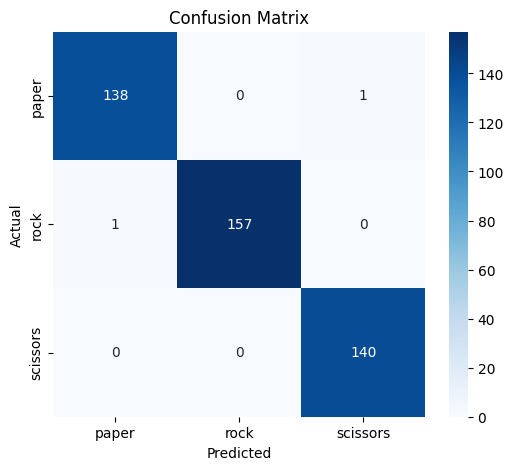

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [15]:
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    class_index = np.argmax(prediction)

    print("Prediction:", class_names[class_index])
    print("Confidence:", float(prediction[0][class_index]) * 100, "%")

# Example:
predict_image("/content/TEST (1).jpg")



Prediction: scissors
Confidence: 65.49108624458313 %


In [16]:
predict_image("/content/TEST (1).jpg")

Prediction: scissors
Confidence: 65.49108624458313 %


In [18]:
predict_image("/content/TEST (3).jpg")

Prediction: paper
Confidence: 96.15801572799683 %


In [22]:
predict_image("/content/dataset/ML/rps cnn/test_images.jpg")

Prediction: scissors
Confidence: 95.72240710258484 %


In [23]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


In [29]:
filename = take_photo()
print("Saved to", filename)


<IPython.core.display.Javascript object>

Saved to photo.jpg


In [30]:
predict_image(filename)


Prediction: paper
Confidence: 98.92202019691467 %
